In [1]:
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

In [2]:
import phd_parser as pp

In [3]:
from phd_parser.raman.renishaw import read_export_txt, read_export_wdf

In [4]:
mock_txt_785 = Path(r"..\tests\raman\renishaw\TiO2_Julius_785_1acc_01.txt")
mock_txt_532 = Path(r"..\tests\raman\renishaw\TiO2_Julius_532_1acc_01.txt")
mock_wdf = Path(r"..\tests\raman\renishaw\TiO2_Julius_532_1acc_01.wdf")

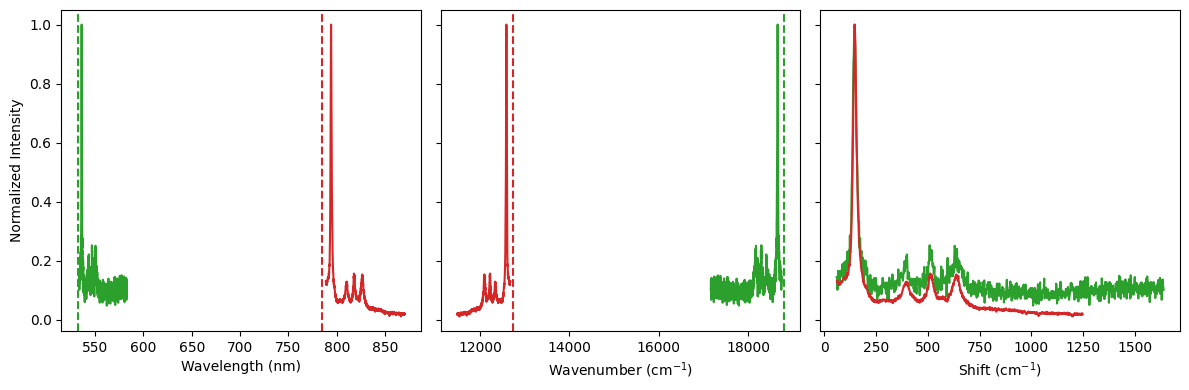

In [13]:
raman_txt_785 = pp.raman.RamanData.from_renishaw_txt(mock_txt_785, excitation_wavelength_nm=785)
raman_txt_532 = pp.raman.RamanData.from_renishaw_txt(mock_txt_532, excitation_wavelength_nm=532)

fig, axes = plt.subplots(1, 3, figsize = (12, 4),  sharey=True)
ax = axes.flatten()[0]
ax.plot(raman_txt_532.wavelength_nm,  raman_txt_532.values / np.max(raman_txt_532.values), label="532 nm", color = "tab:green")
ax.axvline(raman_txt_532.excitation_wavelength_nm, color="tab:green", linestyle="--", label="532 nm excitation")
ax.plot(raman_txt_785.wavelength_nm, raman_txt_785.values / np.max(raman_txt_785.values), label="785 nm", color = "tab:red")
ax.axvline(raman_txt_785.excitation_wavelength_nm, color="tab:red", linestyle="--", label="785 nm excitation")
ax.set_xlabel("Wavelength (nm)")
ax.set_ylabel("Normalized Intensity")

ax = axes.flatten()[1]
ax.plot(raman_txt_532.wavenumber_per_cm,  raman_txt_532.values / np.max(raman_txt_532.values), label="532 nm", color = "tab:green")
ax.axvline(raman_txt_532.excitation_wavenumber_per_cm, color="tab:green", linestyle="--", label="532 nm excitation")
ax.plot(raman_txt_785.wavenumber_per_cm, raman_txt_785.values / np.max(raman_txt_785.values), label="785 nm", color = "tab:red")
ax.axvline(raman_txt_785.excitation_wavenumber_per_cm, color="tab:red", linestyle="--", label="785 nm excitation")
ax.set_xlabel("Wavenumber (cm$^{-1}$)")

ax = axes.flatten()[2]
ax.plot(raman_txt_532.shift_per_cm,  raman_txt_532.values / np.max(raman_txt_532.values), label="532 nm", color = "tab:green")
ax.plot(raman_txt_785.shift_per_cm, raman_txt_785.values / np.max(raman_txt_785.values), label="785 nm", color = "tab:red")
ax.set_xlabel("Shift (cm$^{-1}$)")

plt.tight_layout()
plt.show()

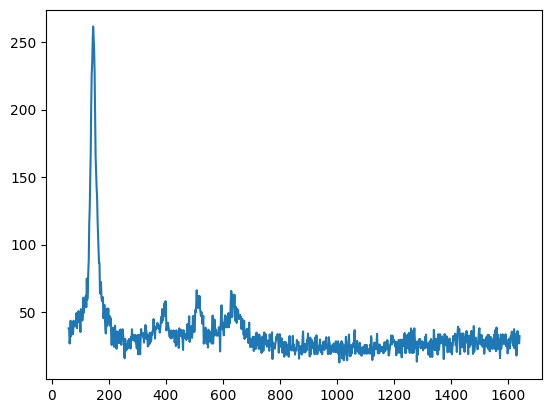

In [14]:
raman_wdf = pp.raman.RamanData.from_renishaw_wdf(mock_wdf)
fig, ax = plt.subplots()
ax.plot(raman_wdf.shift_per_cm, raman_wdf.values)

In [18]:
wdf = raman_wdf.metadata["WDFResult"]

In [19]:
wdf.data

array([32.09693146, 26.74744415, 28.52114677, ..., 26.6658802 ,
       37.88819885, 37.88278961], shape=(1017,))

In [ ]:
mew = (wdf.laser_cm1 - wdf.wavenumber)

In [ ]:
wavelength = 1e7 / mew
wavelength

array([582.91751125, 582.87145704, 582.82534375, ..., 533.83736478,
       533.78822098, 533.73908623], shape=(1017,))